In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ru-bridge-telegram/zarussia_1_green_df.csv
/kaggle/input/ru-bridge-telegram/Lunay14_green_df.csv
/kaggle/input/ru-bridge-telegram/ua_tribunal_red_df.csv
/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv
/kaggle/input/ru-bridge-telegram/domain_pc1.csv
/kaggle/input/ru-bridge-telegram/rtdru_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/orchestra_w_green_df.csv
/kaggle/input/ru-bridge-telegram/Bridge_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/Seed_Channels_domain_analysis.csv
/kaggle/input/ru-bridge-telegram/rustroyka1945_green_df.csv
/kaggle/input/ru-bridge-telegram/novosti_efir_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/warfakebelgorod_green_df.csv
/kaggle/input/ru-bridge-telegram/msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/CyberfrontZ_msg_csv_urls_only.csv
/kaggle/input/ru-bridge-telegram/heroesofZ_msgs_dataset.csv
/kaggle/input/ru-bridge-telegram/voin_dv_green_df.csv


In [2]:
bridge_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/bridge_full_msg_csv.csv", low_memory=False)
seed_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/msgs_dataset.csv", low_memory=False)
domain_rating_df = pd.read_csv(r"/kaggle/input/ru-bridge-telegram/domain_pc1.csv", low_memory=False)

seed_df['is_bridge'] = False
bridge_df['is_bridge'] = True

In [3]:
combined_df = pd.concat([seed_df, bridge_df], ignore_index=True)
combined_filtered_df = combined_df[combined_df['has_url'] == 1]
combined_filtered_df['date'] = pd.to_datetime(combined_filtered_df['date'])

<ipython-input-3-617ceead5a0c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['date'] = pd.to_datetime(combined_filtered_df['date'])


In [4]:
print(len(combined_df), '\t', len(combined_filtered_df))

1091521 	 107477


In [5]:
len(combined_filtered_df['url'].unique())

97025

In [6]:
# import matplotlib.pyplot as plt
# import pandas as pd

# unique_urls = combined_filtered_df['url'].unique()

# plt.figure(figsize=(15, 10))

# for url in unique_urls:
#     url_data = combined_filtered_df[combined_filtered_df['url'] == url]
    
#     url_data = url_data.sort_values('date')
#     color = 'red' if url_data['is_bridge'].iloc[0] else 'blue'
    
#     plt.plot(url_data['date'], url_data['views'], label=url, color=color, alpha=0.7)

# plt.xlabel('Date')
# plt.ylabel('Views')
# plt.title('Trajectory of Views for Each URL')
# plt.legend(title='URLs', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# plt.tight_layout()

# plt.show()

In [7]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Filter only necessary columns and rows with URLs
url_df = seed_df[['date', 'url', 'views']][seed_df['has_url'] == True].copy()
url_df = url_df

# 2. Get URLs that appear multiple times
url_counts = url_df['url'].value_counts()
multiple_urls = url_counts[url_counts > 1].index

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = url_df[url_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_views': group['views'].cumsum()
    })

# 6. Create plot with Plotly
fig = go.Figure()

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_views'],
            name=data['url'][:30] + '...',
            mode='lines'
        )
    )

fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800
)

# if len(multiple_urls):
#     fig.data = fig.data

fig.show()

In [8]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Filter only necessary columns and rows with URLs
url_df = combined_filtered_df[['date', 'url', 'views', 'is_bridge']][combined_filtered_df['has_url'] == True].copy()
url_df = url_df

# 2. Get URLs that appear multiple times
conflicting_links = url_df.groupby('url')['is_bridge'].nunique()
multiple_urls = conflicting_links[conflicting_links > 1].index.tolist()
# url_counts = url_df['url'].value_counts()
# multiple_urls = url_counts[url_counts > 1].index

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = url_df[url_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_views': group['views'].cumsum()
    })

# 6. Create plot with Plotly
fig = go.Figure()

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_views'],
            name=data['url'][8:45],
            mode='lines',
            line=dict(color='blue') 
        )
    )

fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800
)

fig.show()

In [9]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

url_df = combined_filtered_df[['date', 'url', 'views', 'is_bridge']][combined_filtered_df['has_url'] == True].copy()
# url_df = seed_df[['date', 'url', 'views','is_bridge']][seed_df['has_url'] == True].copy()

# 2. Get URLs that appear multiple times
conflicting_links = url_df.groupby('url')['is_bridge'].nunique()
multiple_urls = conflicting_links[conflicting_links > 1].index.tolist()
# url_counts = url_df['url'].value_counts()
# multiple_urls = url_counts[url_counts > 1].index

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = seed_df[seed_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_views': group['views'].cumsum()
    })

# 6. Create plot with Plotly
fig = go.Figure()

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_views'],
            name=data['url'][8:45],
            mode='lines',
            line=dict(color='blue') 
        )
    )


# 1. Filter only necessary columns and rows with URLs
# url_df = combined_filtered_df[['date', 'url', 'views', 'is_bridge']][combined_filtered_df['has_url'] == True].copy()
# url_df = url_df

# # 2. Get URLs that appear multiple times
# conflicting_links = url_df.groupby('url')['is_bridge'].nunique()
# multiple_urls = conflicting_links[conflicting_links > 1].index.tolist()

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = bridge_df[bridge_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_views': group['views'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_views'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='red') 
        )
    )

filtered_df = combined_filtered_df[combined_filtered_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_views': group['views'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_views'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='green') 
        )
    )


fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800
)

fig.show()

In [10]:
fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800,
    yaxis=dict(
        range=[0, 2_500_000],
        tickformat=',.0f'
    )
)

fig.show()

In [11]:
from datetime import datetime
fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800,
    yaxis=dict(
        range=[0, 500_000],
        tickformat=',.0f'
    ),
    xaxis=dict(
        range=[datetime(2022, 1, 1),datetime(2024, 1, 1)]
    )
)

fig.show()

In [12]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

url_df = combined_filtered_df[['date', 'url', 'number_forwards', 'is_bridge']][combined_filtered_df['has_url'] == True].copy()
# url_df = seed_df[['date', 'url', 'views','is_bridge']][seed_df['has_url'] == True].copy()

# 2. Get URLs that appear multiple times
conflicting_links = url_df.groupby('url')['is_bridge'].nunique()
multiple_urls = conflicting_links[conflicting_links > 1].index.tolist()
# url_counts = url_df['url'].value_counts()
# multiple_urls = url_counts[url_counts > 1].index

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = seed_df[seed_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_forwards': group['number_forwards'].cumsum()
    })

# 6. Create plot with Plotly
fig = go.Figure()

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_forwards'],
            name=data['url'][8:45],
            mode='lines',
            line=dict(color='blue') 
        )
    )


# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = bridge_df[bridge_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_forwards': group['number_forwards'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_forwards'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='red') 
        )
    )

filtered_df = combined_filtered_df[combined_filtered_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_forwards': group['number_forwards'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_forwards'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='green') 
        )
    )


fig.update_layout(
    title='Cumulative forwards Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative forwards',
    showlegend=True,
    height=800
)

fig.show()

In [13]:


fig.update_layout(
    title='Cumulative forwards Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative forwards',
    showlegend=True,
    height=800,
    yaxis=dict(
        range=[0, 3_000],
        tickformat=',.0f'
    ),
)

fig.show()

In [14]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

url_df = combined_filtered_df[['date', 'url', 'number_replies', 'is_bridge']][combined_filtered_df['has_url'] == True].copy()
# url_df = seed_df[['date', 'url', 'views','is_bridge']][seed_df['has_url'] == True].copy()

# 2. Get URLs that appear multiple times
conflicting_links = url_df.groupby('url')['is_bridge'].nunique()
multiple_urls = conflicting_links[conflicting_links > 1].index.tolist()
# url_counts = url_df['url'].value_counts()
# multiple_urls = url_counts[url_counts > 1].index

# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = seed_df[seed_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_replies': group['number_replies'].cumsum()
    })

# 6. Create plot with Plotly
fig = go.Figure()

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_replies'],
            name=data['url'][8:45],
            mode='lines',
            line=dict(color='blue') 
        )
    )


# 3. Filter dataframe to include only multiple occurrence URLs
filtered_df = bridge_df[bridge_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_replies': group['number_replies'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_replies'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='red') 
        )
    )

filtered_df = combined_filtered_df[combined_filtered_df['url'].isin(multiple_urls)]

# 4. Sort by date and group by URL
filtered_df = filtered_df.sort_values('date')
grouped = filtered_df.groupby('url')

# 5. Calculate cumulative views for each URL
cumulative_data = []
for url, group in grouped:
    cumulative_data.append({
        'url': url,
        'dates': group['date'],
        'cumulative_replies': group['number_replies'].cumsum()
    })

for data in cumulative_data:
    fig.add_trace(
        go.Scatter(
            x=data['dates'],
            y=data['cumulative_replies'],
            name=data['url'][8:45],
            mode='lines', 
            line=dict(color='green') 
        )
    )


fig.update_layout(
    title='Cumulative replies Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative replies',
    showlegend=True,
    height=800
)

fig.show()

In [15]:
from datetime import datetime
fig.update_layout(
    title='Cumulative Views Trajectory for Multiple-Occurrence URLs',
    xaxis_title='Date',
    yaxis_title='Cumulative Views',
    showlegend=True,
    height=800,
    yaxis=dict(
        range=[0, 300],
        tickformat=',.0f'
    ),
    xaxis=dict(
        range=[datetime(2023, 6, 1),datetime(2024, 6, 1)]
    )
)

fig.show()

In [16]:
conflicting_links = combined_filtered_df.groupby('url')['is_bridge'].nunique()
conflicting_links = conflicting_links[conflicting_links == 2].index.tolist()

In [17]:
len(conflicting_links)

398

<ipython-input-18-8d765d4dae8f>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



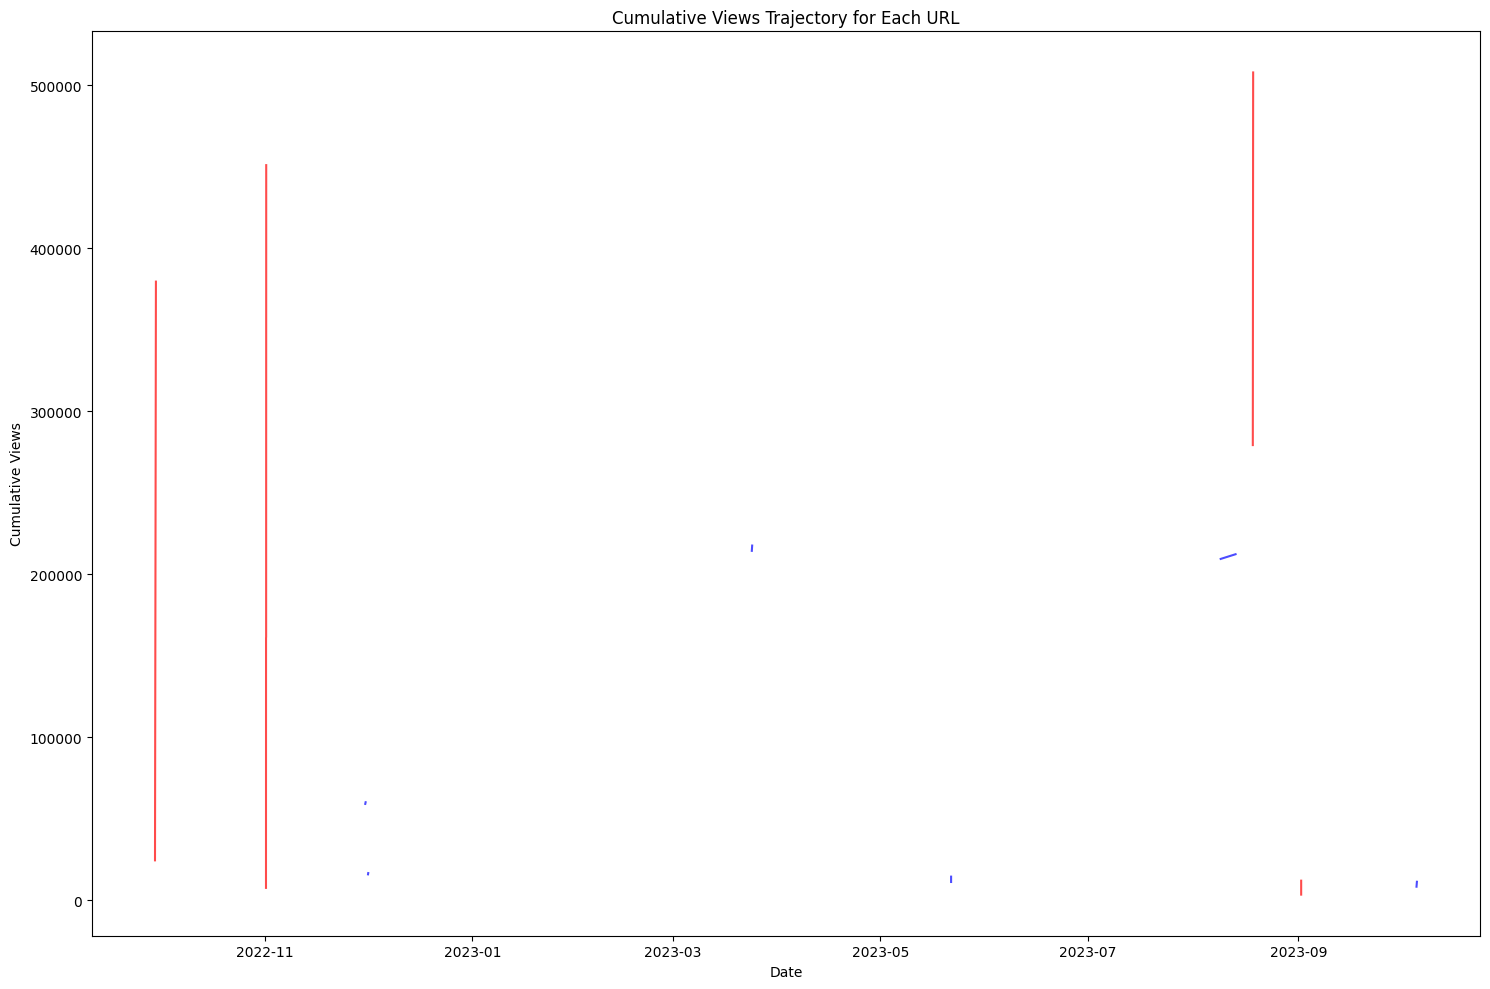

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

combined_filtered_df['date'] = pd.to_datetime(combined_filtered_df['date'])

plt.figure(figsize=(15, 10))

for url in conflicting_links[:10]:
    url_data = combined_filtered_df[combined_filtered_df['url'] == url]
    
    url_data = url_data.sort_values('date')
    
    url_data['cumulative_views'] = url_data['views'].cumsum()
    
    color = 'red' if url_data['is_bridge'].iloc[0] else 'blue'
    
    plt.plot(url_data['date'], url_data['cumulative_views'], label=url, color=color, alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Cumulative Views')
plt.title('Cumulative Views Trajectory for Each URL')
plt.tight_layout()

plt.show()

In [19]:
url_data['date']

48067    2023-05-21 20:09:41+00:00
957066   2023-05-21 20:12:03+00:00
Name: date, dtype: datetime64[ns, UTC]

In [20]:
url_data['cumulative_views']

48067     11176
957066    14451
Name: cumulative_views, dtype: int64

In [21]:
url_data['views']

48067     11176
957066     3275
Name: views, dtype: int64

In [22]:
url_data['is_bridge']

48067     False
957066     True
Name: is_bridge, dtype: bool